# CSCI 3352 Biological Networks, Prof. Clauset

# Final Project: Mutualistic Plant-Animal Networks & Power-law fit

***

**Name**: Dominic Galgano

***

In [13]:
# Import necessary packages
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt

import powerlaw #Imports the powerlaw package for fitting the data to the powerlaw curve

%matplotlib inline

### Create a function to read in cvs formatted data and display it as a bipartite graph

In [31]:
def bipartite_from_cvs(filename):  
    bezerra = np.genfromtxt(filename,delimiter=',')
    rows = bezerra.shape[0]
    cols = bezerra.shape[1]

    G = nx.DiGraph()
    nodes = []
    z = {}

    #Pull out nodes
    for plant in range(rows):
        p_name = "P" + str(plant)
        nodes.append(p_name)
        z[p_name] = 0

    for animal in range(cols):
        a_name = "A" + str(animal)
        nodes.append(a_name)
        z[a_name] = 1

    G.add_nodes_from(nodes)

    #Add edges
    for plant in range(rows):
        p_name = "P" + str(plant)
        for animal in range(cols):
            a_name = "A" + str(animal)

            if bezerra[plant][animal] > 0:
                #print("Plant:", p_name, " Animal:", a_name, " edge:", bezerra[plant][animal])
                G.add_edge(p_name,a_name,weight=1)
                G.add_edge(a_name,p_name,weight=1)
    
    #Draw the graph the way I want it to look
    pos = {}
    plants = []
    animals = []
    for i, node in enumerate(nodes):
        if z[node] == 0:
            pos[node] = (0, -i)
            plants.append(node)
        else:
            pos[node] = (1, -i + len(nodes) / 2)
            animals.append(node)

    #print(plants)
    #print(animals)

    nx.draw_networkx(G, pos=pos, with_labels=True)
    nx.draw_networkx_nodes(G, pos=pos, nodelist=animals, node_color='red')
    plt.title(filename + " Bipartite Graph")
    plt.show()
    
    return G, z

### Import data from cvs and display

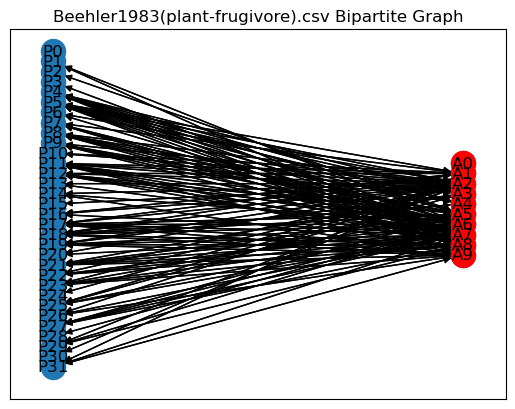

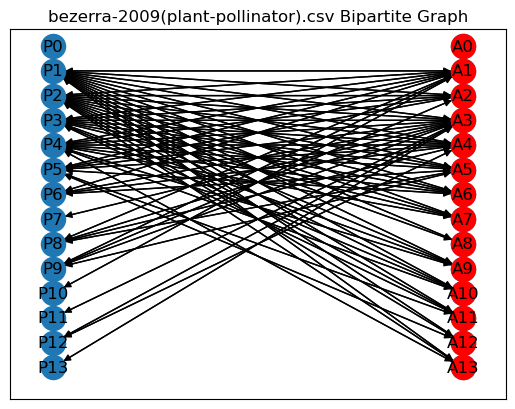

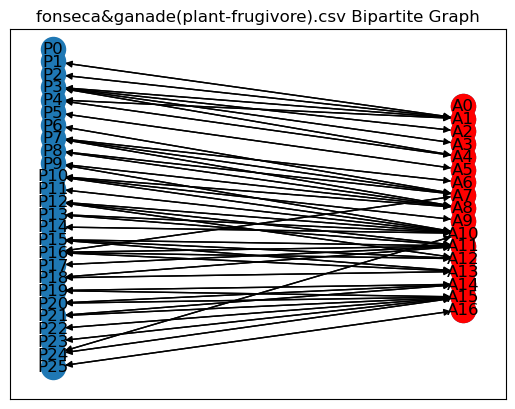

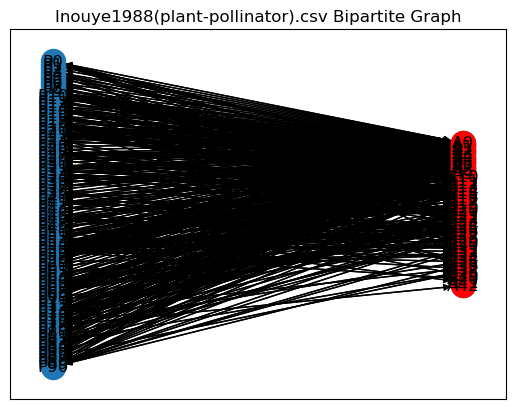

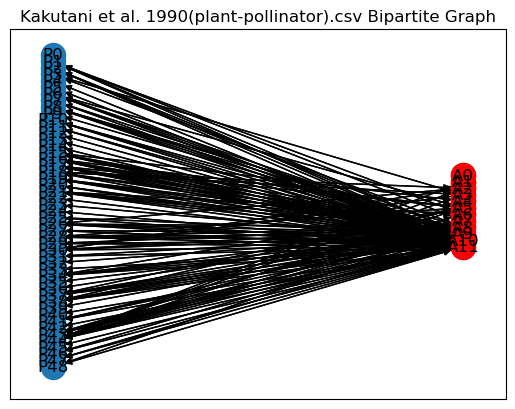

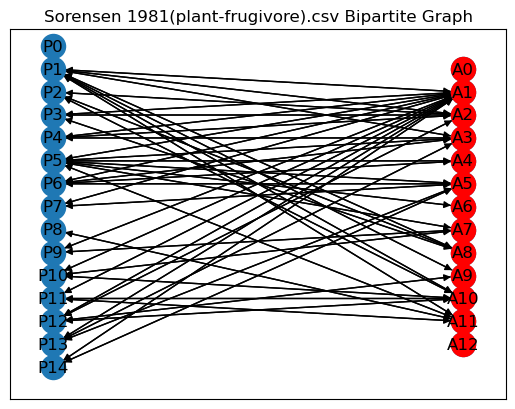

In [32]:
networks = ['Beehler1983(plant-frugivore).csv',
            'bezerra-2009(plant-pollinator).csv',
            'fonseca&ganade(plant-frugivore).csv',
            'Inouye1988(plant-pollinator).csv',
            'Kakutani et al. 1990(plant-pollinator).csv',
            'Sorensen 1981(plant-frugivore).csv']
#print(pollinators)

graphs = {}
all_z = {}

for network in networks:
    G, z = bipartite_from_cvs(network)
    graphs[network] = G
    all_z[network] = z


### Produce general network stats

In [33]:
def compute_MGD(G):
    # input : a networkx graph G
    # output: the mean geodesic path length (defined in Lecture 2)

    # YOUR CODE HERE
    output = nx.all_pairs_shortest_path_length(G)
    
    num_paths = 0 #Tracks total number of paths in graph with lengths greater than 0 and less than infinity
    total_distance = 0 #Tracks the total distance of all shortest paths with lengths greater than 0 and less than infinity 
    for x, y in output: #Cycles through all pairs of shortest path lengths
        ##print(x, y)
        #Sums together current shortest path number with total number of shortest paths
        #Subtracts 1 to avoid counting the path of length 0 from a node into itself
        num_paths = num_paths + (len(y.values()) - 1) 
        #Sums together current shortest path distance with total distance of shortest paths
        total_distance = total_distance + sum(y.values()) 
    
    if(num_paths > 0):
        mean = total_distance / num_paths
    else:
        print("No paths exists! Determining <l> to be 0.")
        mean = 0
    
    return mean

def general_stats(G):
    #Gets number of nodes in graph
    n = G.number_of_nodes()
    #Gets the number of edges and stores them in m
    m = G.number_of_edges()
    #Calculates <k> using m and n from above
    kmean = 2 * m / n
    #Gets transitivity of graph
    C = nx.transitivity(G)
    #Gets average shorest path from graph
    ellmean = compute_MGD(G)
    
    #Print the summary stats
    print(f'number of nodes, n  = {n}')
    print(f'number of edges, m  = {m}')
    print(f'mean degree   , <k> = %5.2f' % kmean)
    print(f'clustering coefficient, C     = %5.2f' % C)
    print(f'mean geodesic distance, <ell> = %5.2f' % ellmean)
    
    return n,m,kmean,C,ellmean

In [37]:
for name, G in graphs.items():
    print(name)
    general_stats(G)
    print()

Beehler1983(plant-frugivore).csv
number of nodes, n  = 42
number of edges, m  = 238
mean degree   , <k> = 11.33
clustering coefficient, C     =  0.00
mean geodesic distance, <ell> =  2.23

bezerra-2009(plant-pollinator).csv
number of nodes, n  = 28
number of edges, m  = 142
mean degree   , <k> = 10.14
clustering coefficient, C     =  0.00
mean geodesic distance, <ell> =  2.11

fonseca&ganade(plant-frugivore).csv
number of nodes, n  = 43
number of edges, m  = 96
mean degree   , <k> =  4.47
clustering coefficient, C     =  0.00
mean geodesic distance, <ell> =  3.64

Inouye1988(plant-pollinator).csv
number of nodes, n  = 134
number of edges, m  = 744
mean degree   , <k> = 11.10
clustering coefficient, C     =  0.00
mean geodesic distance, <ell> =  2.45

Kakutani et al. 1990(plant-pollinator).csv
number of nodes, n  = 61
number of edges, m  = 268
mean degree   , <k> =  8.79
clustering coefficient, C     =  0.00
mean geodesic distance, <ell> =  2.35

Sorensen 1981(plant-frugivore).csv
numbe

### Apply power law to data

In [60]:
#Generate data
def power_law(G):
    k = []
    for node in G.nodes:
        k_i = len(list(G.neighbors(node)))
        #print(k_i)
        if k_i > 0:
            k.append(k_i)

    #print("K:", sorted(k))
    data = np.array(k) # data can be list or numpy array
    results = powerlaw.Fit(data)
    gamma = results.power_law.alpha
    k_min = results.power_law.xmin
    print("Gamma:", gamma)
    print("k_min:", k_min)
    R, p = results.distribution_compare('power_law', 'lognormal')
    print("Power-law vs Log-normal:",R, p)
    R, p = results.distribution_compare('power_law', 'exponential')
    print("Power-law vs Exponential:",R, p)
    
    return results, k


def plot_power_law(k, fit, name):
    # input : a list of degrees, e.g., from a networkx graph G
    # output: a plot of the PDF of the degree distribution Pr(k) on log-log axes for k>=1
    
    kmax = max(k)

    # histogram and plot
    counts, bins = np.histogram(k, bins=[i for i in range(kmax+2)], density=True)
    #plt.semilogx(bins[1:-1], counts[1:], 'rs-', alpha=0.5)
    #plt.show()
    plt.loglog(bins[1:-1], counts[1:], 'rs', alpha=0.5)
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(k)')
    plt.title(name + "PDF Log-Log")
    
    # Plot the data
    figPDF = powerlaw.plot_pdf(k, color='b')
    figPDF.set_ylabel("P(k)")
    figPDF.set_xlabel(r"Species interactions(k)")
    figname = 'FigPDF'
    plt.show()
      
    return

def plot_pdf_v_cdf(fit):
    fig = fit.plot_pdf(color='b', linewidth=2)
    fit.power_law.plot_pdf(color='b', linestyle='--', ax=fig)
    fit.plot_ccdf(color='r', linewidth=2, ax=fig)
    fit.power_law.plot_ccdf(color='r', linestyle='--', ax=fig)
    fig.set_ylabel("P(k), P(K >= k)")
    fig.set_xlabel(r"Species Interactions(k)")
    plt.show()
    
    return

Calculating best minimal value for power law fit
Gamma: 3.269137059062801
k_min: 6.0
Power-law vs Log-normal: -0.04849915139103622 0.7849615188697417
Power-law vs Exponential: 1.2107186883870145 0.3979138843907687


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


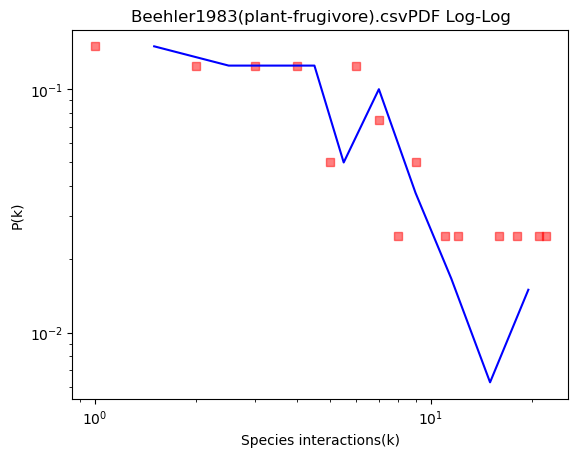

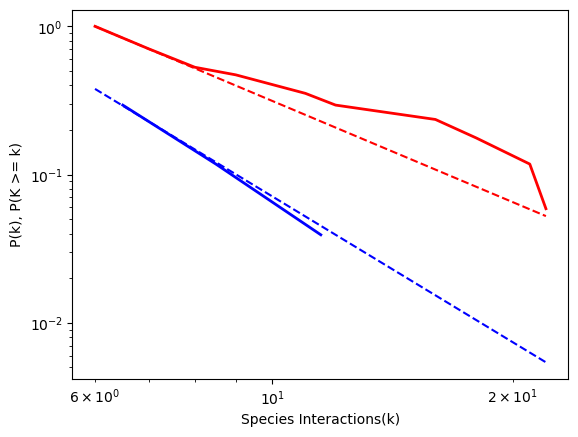

Calculating best minimal value for power law fit
Gamma: 3.1076243437026116
k_min: 4.0
Power-law vs Log-normal: -0.03518080504238541 0.8881623013197159
Power-law vs Exponential: 0.3560243370893681 0.8327011614235822


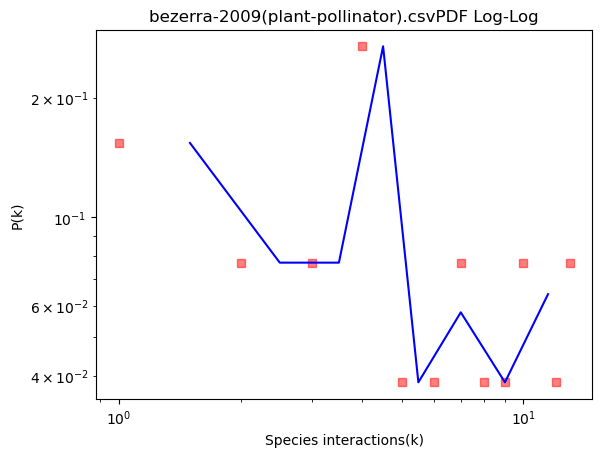

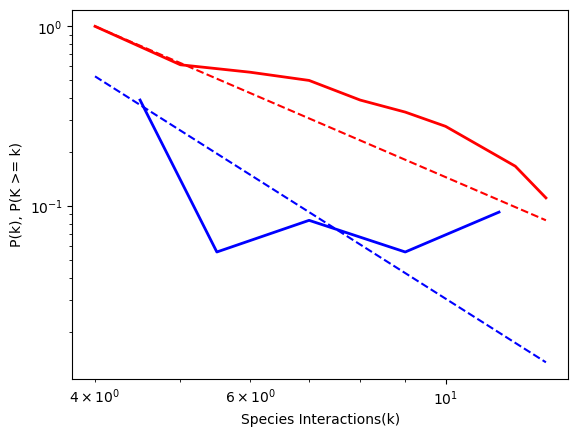

Calculating best minimal value for power law fit
Gamma: 5.084964445917146
k_min: 3.0
Power-law vs Log-normal: -0.010188802526704399 0.029083798320199993
Power-law vs Exponential: 0.9585084567758879 0.2892078355883744


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


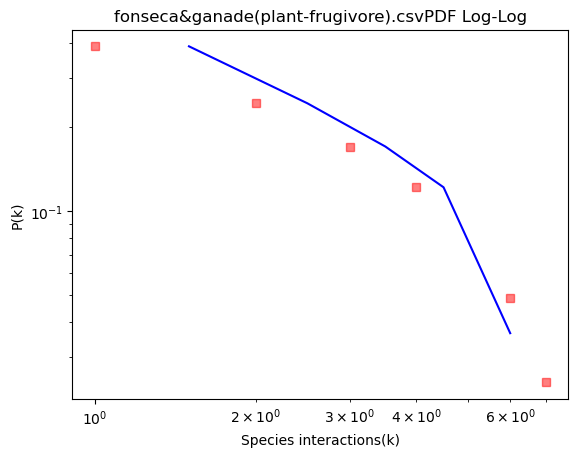

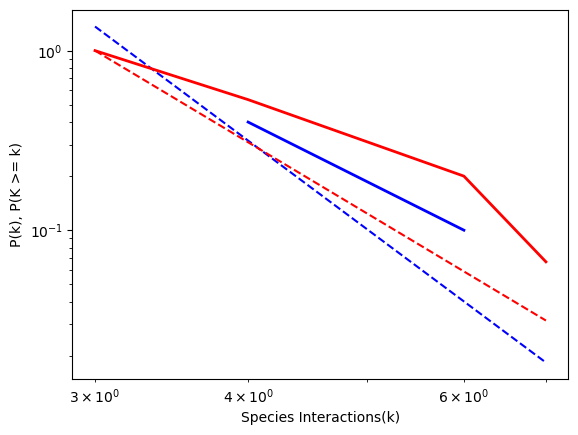

Calculating best minimal value for power law fit
Gamma: 2.4830891620224156
k_min: 2.0
Power-law vs Log-normal: -0.763927970326864 0.26198011956211653
Power-law vs Exponential: 44.21688821502721 0.009993693428299125


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


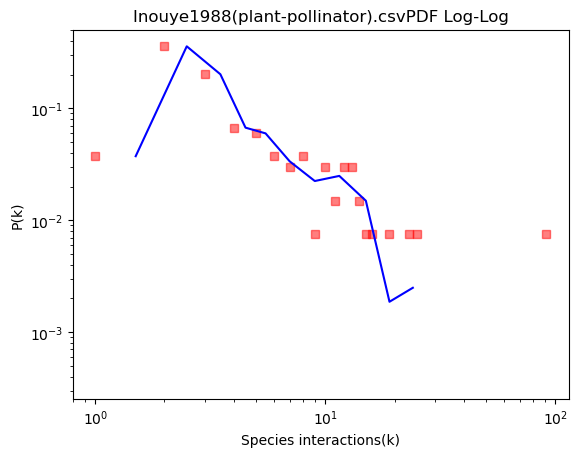

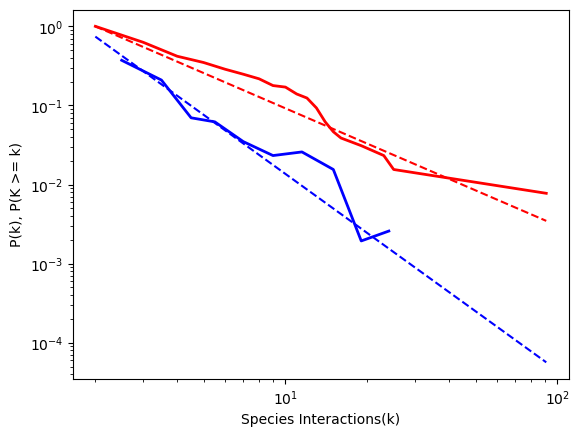

Calculating best minimal value for power law fit
Gamma: 3.0374253682704118
k_min: 4.0
Power-law vs Log-normal: -0.2624564644988465 0.1667722908170175
Power-law vs Exponential: 9.842722096878544 6.545447508214776e-05


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


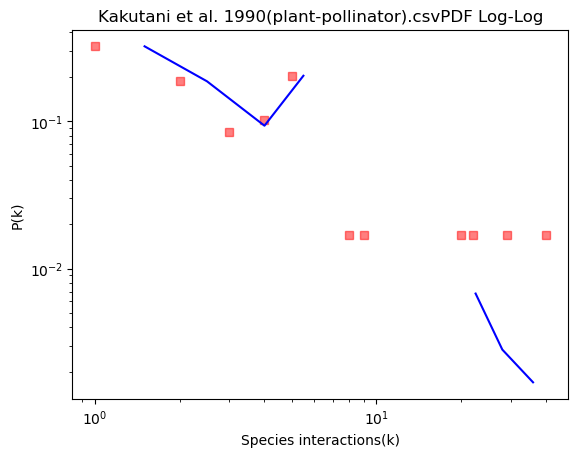

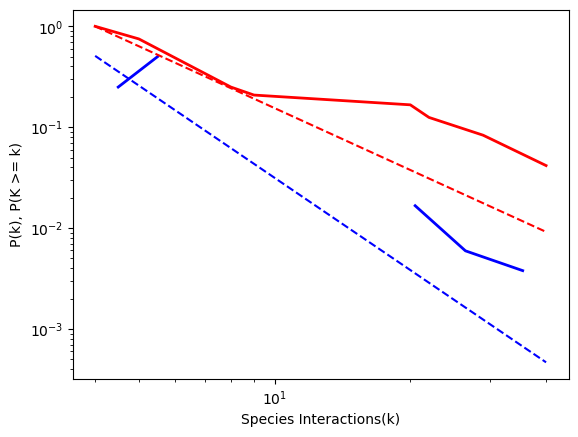

Calculating best minimal value for power law fit
Gamma: 4.006394202465342
k_min: 3.0
Power-law vs Log-normal: 0.0020183080280543365 0.800157209366773
Power-law vs Exponential: 2.004075136947165 0.20611154888636207


'nan' in fit cumulative distribution values.
Likely underflow or overflow error: the optimal fit for this distribution gives values that are so extreme that we lack the numerical precision to calculate them.


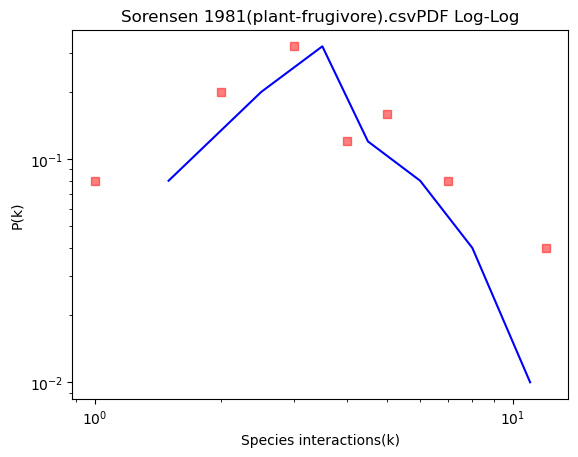

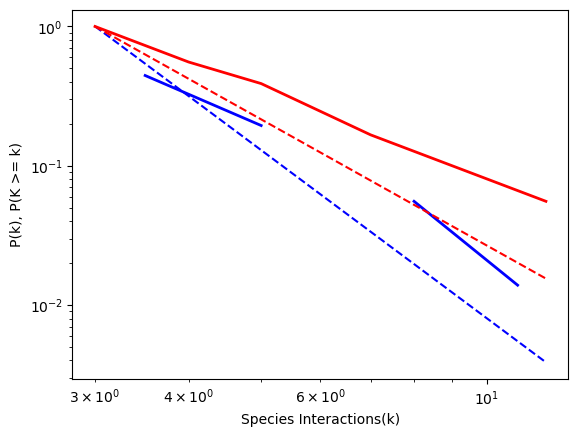

In [61]:
for name, graph in graphs.items():
    fit, k = power_law(graph)
    plot_power_law(k, fit, name)
    plot_pdf_v_cdf(fit)


### PDF vs CDF